In [61]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from datetime import datetime
import math

In [63]:
#https://www.kaggle.com/datasets/rodsaldanha/arketing-campaign/data
data = pd.read_csv(path+File, sep=';' )
# from google.colab import sheets
# sheet = sheets.InteractiveSheet(df=data)

In [64]:
data.tail(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,2012-10-15,40,84,...,7,0,0,0,0,0,0,3,11,1


### Data Preprocessing:


In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [66]:
data['Income'].isnull().sum()

np.int64(24)

In [67]:
##Income likely depends on Education or Marital_Status. You can impute by group median.

data['Income'] = data.groupby(['Education', 'Marital_Status'])['Income'] \
                  .transform(lambda x: x.fillna(x.median()))
data['Income'].isnull().sum()

np.int64(0)

###Feature Engineering


In [68]:
#Variable Age in replacement of the variable Year_birth
current_year = datetime.now().year
data['Age'] = current_year - data['Year_Birth']

#drop Year_Birth, we  don’t need it:
data.drop(columns=['Year_Birth'], inplace=True)

In [69]:
## Variable Spending as the sum of the amount spent on the 6 product categories

data['Spending'] = (
    data['MntWines'] +
    data['MntFruits'] +
    data['MntMeatProducts'] +
    data['MntFishProducts'] +
    data['MntSweetProducts'] +
    data['MntGoldProds']
)




In [70]:
##Marital_Situation — grouping into “In couple” vs “Alone”
print(data['Marital_Status'].unique())

data['Marital_Situation'] = data['Marital_Status'].replace({
    'Married': 'In_couple',
    'Together': 'In_couple',
    'Single': 'Alone',
    'Divorced': 'Alone',
    'Widow': 'Alone',
    'Alone': 'Alone',
    'YOLO': 'Alone',
    'Absurd': 'Alone'
})

#drop marital status, no lonhger needed
data.drop(columns=['Marital_Status'], inplace=True)

data['Marital_Situation'].unique()

['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


array(['Alone', 'In_couple'], dtype=object)

In [71]:
#combine the variables  kidhome and teenhome into just one variable 'Has_child

data['No_children'] = ((data['Kidhome'] + data['Teenhome']) > 0).astype(int)

#or Y/N instead on int
#data['Has_child'] = ((data['Kidhome'] + data['Teenhome']) > 0).astype(int)

data.drop(columns='Kidhome' , inplace=True)
data.drop(columns='Teenhome' , inplace=True)

In [72]:
education_years_map = {
    'Basic': 9,
    'HighSchool': 12,
    'undergrad': 16,
    'Master': 18,
    'PhD': 21
}

data['Educational_years'] = data['Education'].map(education_years_map)

data.drop(columns=['Education'], inplace=True)

In [73]:
#not useful for the analysis features
data.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'], inplace=True)

In [74]:
data.head()

,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Spending,Marital_Situation,No_children,Educational_years
0,58138.0,2012-09-04,58,635,88,546,172,88,88,3,...,0,0,0,0,1,69,1617,Alone,0,NaN
1,46344.0,2014-03-08,38,11,1,6,2,1,6,2,...,0,0,0,0,0,72,27,Alone,1,NaN
2,71613.0,2013-08-21,26,426,49,127,111,21,42,1,...,0,0,0,0,0,61,776,In_couple,0,NaN
3,26646.0,2014-02-10,26,11,4,20,10,3,5,2,...,0,0,0,0,0,42,53,In_couple,1,NaN
4,58293.0,2014-01-19,94,173,43,118,46,27,15,5,...,0,0,0,0,0,45,422,In_couple,1,21.0


### Statitical Summary

In [75]:
data.describe()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Spending,No_children,Educational_years
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,910.000000
mean,52231.860714,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,...,0.074554,0.072768,0.064286,0.013393,0.009375,0.149107,57.194196,605.798214,0.715179,19.068132
std,25039.866195,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,...,0.262728,0.259813,0.245316,0.114976,0.096391,0.356274,11.984069,602.249288,0.451430,2.912319
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,5.000000,0.000000,9.000000
25%,35538.750000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,49.000000,68.750000,0.000000,18.000000
50%,51222.500000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,396.000000,1.000000,21.000000
75%,68289.750000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000,1045.500000,1.000000,21.000000
max,666666.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,133.000000,2525.000000,1.000000,21.000000


---

#EDA


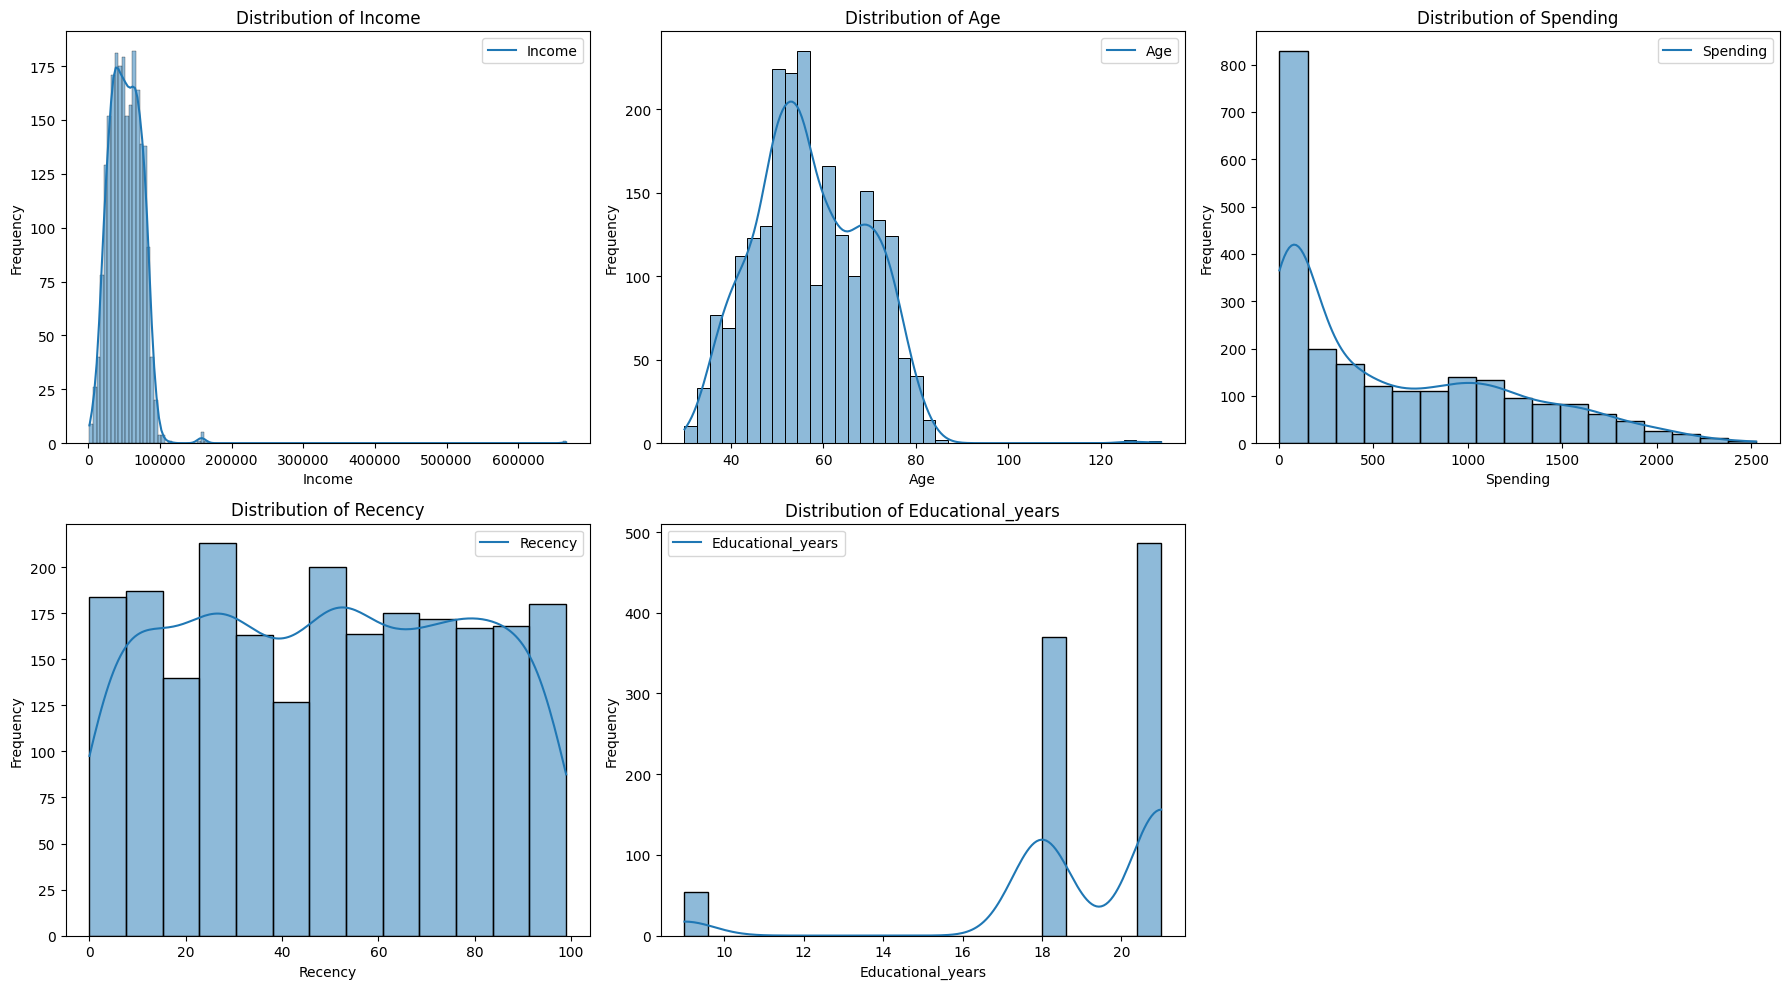

In [76]:
numerical_features = ['Income', 'Age', 'Spending', 'Recency', 'Educational_years']

# Define number of columns
cols = 3
rows = math.ceil(len(numerical_features) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()  # Flatten in case of multiple rows

for i, feature in enumerate(numerical_features):
    sn.histplot(data=data, x=feature, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].legend([feature])

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

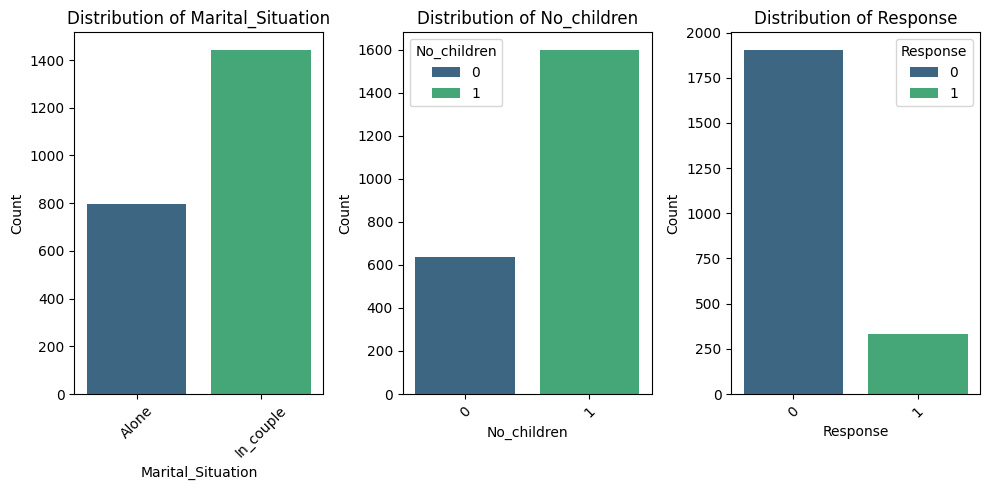

In [77]:
categorical_features = ['Marital_Situation', 'No_children', 'Response']

# Define number of columns
cols = 3
rows = math.ceil(len(categorical_features) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sn.countplot(data=data, x=feature, hue=feature, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)  # rotate labels if crowded

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [78]:
##extract all numerical columns from the DataFrame to prepare for the correlation heatmap visualizatio

numerical_df = data.select_dtypes(include=np.number)
numerical_df.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Spending,No_children,Educational_years
0,58138.0,58,635,88,546,172,88,88,3,8,...,0,0,0,0,0,1,69,1617,0,NaN
1,46344.0,38,11,1,6,2,1,6,2,1,...,0,0,0,0,0,0,72,27,1,NaN
2,71613.0,26,426,49,127,111,21,42,1,8,...,0,0,0,0,0,0,61,776,0,NaN
3,26646.0,26,11,4,20,10,3,5,2,2,...,0,0,0,0,0,0,42,53,1,NaN
4,58293.0,94,173,43,118,46,27,15,5,5,...,0,0,0,0,0,0,45,422,1,21.0


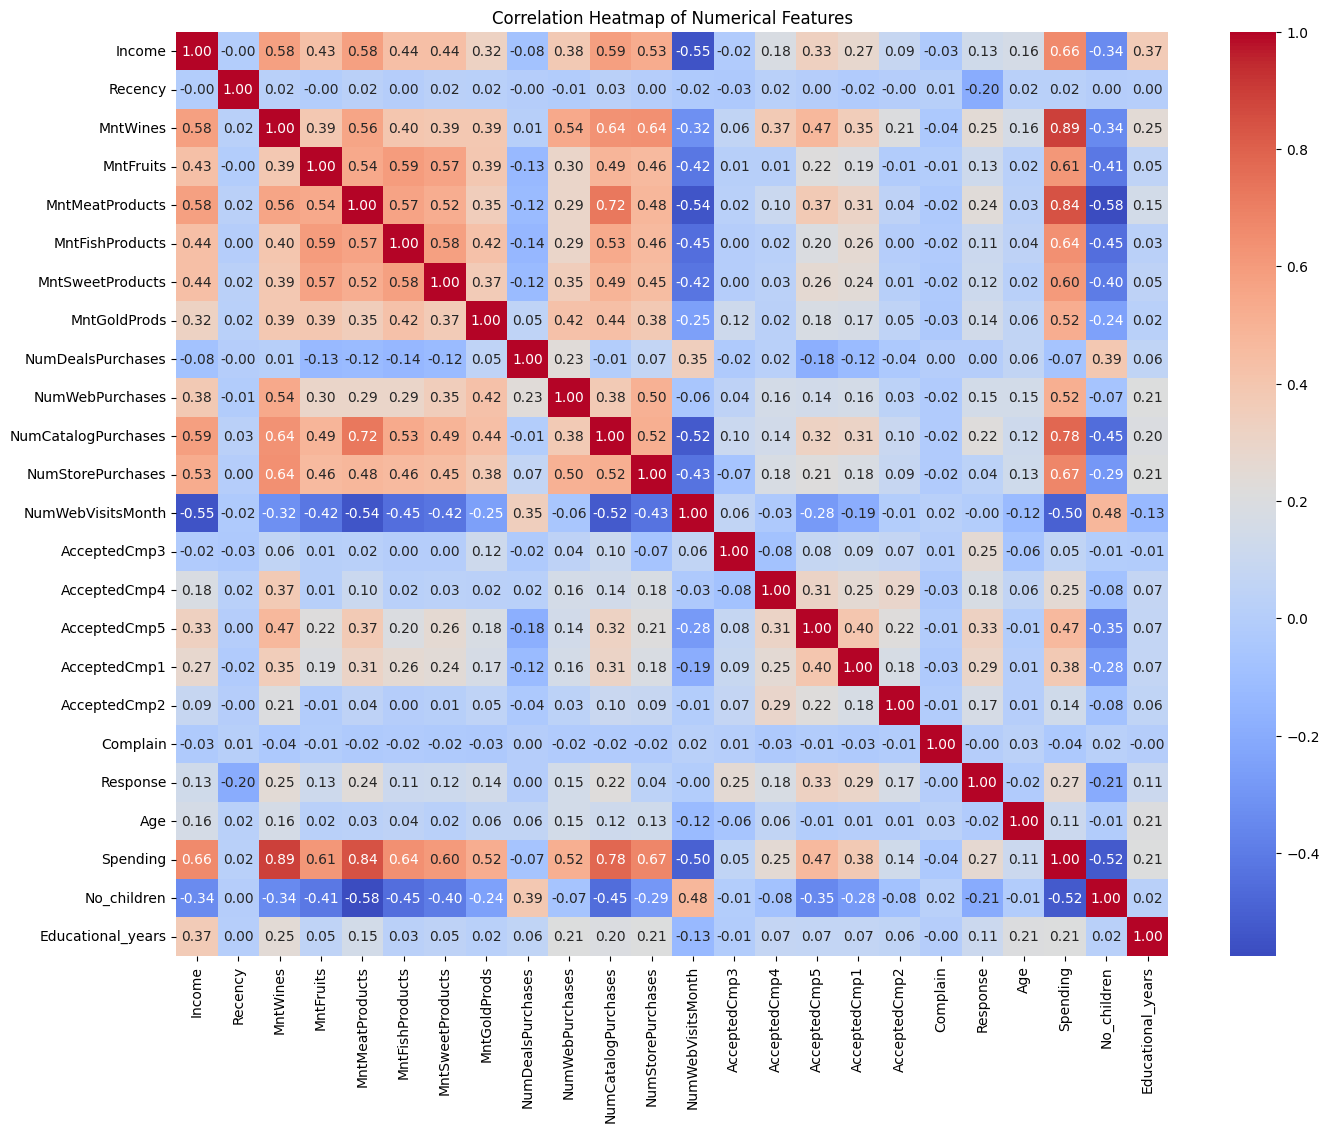

In [79]:
plt.figure(figsize=(16, 12))
sn.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Insights**

      Higher-income customers:

      Spend significantly more

      Buy more premium products (wine, meat)

      Purchase more via catalog and store

In [80]:
np.random.seed(42)
# -----------------------------
# Synthetic dataset
# -----------------------------
n = 1000

education_levels = ["Basic", "2n Cycle", "Graduation", "Master", "PhD"]
marital_status = ["Alone", "In couple"]
parental_status = ["Yes", "No"]

data = pd.DataFrame({
    "Education": np.random.choice(education_levels, n, p=[0.2,0.2,0.3,0.2,0.1]),
    "Marital_Status": np.random.choice(marital_status, n, p=[0.35,0.65]),
    "Parent": np.random.choice(parental_status, n, p=[0.7,0.3]),
})

income_map = {
    "Basic": 20000,
    "2n Cycle": 45000,
    "Graduation": 52000,
    "Master": 55000,
    "PhD": 60000
}

data["Income"] = data["Education"].map(income_map) + np.random.normal(0, 10000, n)
data["Spending"] = data["Income"] * 0.05 + np.random.normal(0, 200, n)

bins = [0,40000,60000,80000,200000]
labels = ["Low income","Low-Medium income","Medium-high income","High income"]
data["Income_Category"] = pd.cut(data["Income"], bins=bins, labels=labels)

# ==========================================================
# 1) Diploma distribution by income level
# ==========================================================
fig1 = px.histogram(
    data,
    x="Income",
    color="Education",
    barmode="overlay",
    nbins=20,
    title="Diploma distribution by income level"
)

fig1.update_layout(template="plotly_white")
fig1.show()


# ==========================================================
# 2) Average income by diploma
# ==========================================================
avg_income = data.groupby("Education", as_index=False)["Income"].mean()

fig2 = px.bar(
    avg_income,
    x="Education",
    y="Income",
    title="Average income by diploma"
)

fig2.update_layout(template="plotly_white")
fig2.show()



In [81]:
# Remove rows with missing income categories
sunburst_data = data.dropna(subset=["Income_Category"])

fig5 = px.sunburst(
    sunburst_data,
    path=["Parent", "Income_Category"],
    title="Income level by parental status"
)

fig5.update_layout(template="plotly_white")
fig5.show()

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [82]:


# ==========================================================
# 3) Spending by Income (with regression line)
# ==========================================================
fig3 = px.scatter(
    data,
    x="Spending",
    y="Income",
    title="Spending by Income",
    opacity=0.7
)

# Manual regression
coef = np.polyfit(data["Spending"], data["Income"], 1)
x_vals = np.linspace(data["Spending"].min(), data["Spending"].max(), 100)
y_vals = coef[0] * x_vals + coef[1]

fig3.add_trace(
    go.Scatter(
        x=x_vals,
        y=y_vals,
        mode="lines",
        name="line of best fit"
    )
)

fig3.update_layout(template="plotly_white")
fig3.show()


# ==========================================================
# 4) Diploma distribution by marital situation
# ==========================================================
fig4 = px.sunburst(
    data,
    path=["Marital_Status", "Education"],
    title="Diploma distribution by marital situation"
)

fig4.update_layout(template="plotly_white")
fig4.show()
